In [1]:
# -*- coding: utf-8 -*-
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import numpy as np
import pandas as pd
import os 
from datetime import datetime
import torch

In [2]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
def run(link, df_link, File, id = 'pred_vdist', load = True):

    N_episodes = 1000
    ep_len     = 5
    
    buffer_size = 6000
    batch_size = 32
    
    # ----- Create a map -----
    
    x_size = 20
    y_size = 30

    list_of_small_pertb = [[0,4], [13,5], [17,25]]
    list_of_big_pert = [[6,9],[17,25]]
    
    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)
    
    # ----- Create a fleet -----
    
    drone_init_pos = [[5,5], [5,20], [18, 4], [19,21]]
      
    state_shape    = [ep_len, 13]    
    alpha = 1e-4
    num_stacked = 2
    
    pretrained_folder = None    
 
    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, gru = True, num_stacked = num_stacked, alpha = alpha) 
    F.add_drones(drone_init_pos)    
    
    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time + "_pretraining_GRU"
    if not os.path.exists(current_results):
        os.makedirs(current_results)    
    
    #----- Simultaion pretraining -----
    load_data_link = r'/Results/pretrain GRU vdist all files'
    
    #F.pretrain(current_results, N_iter=100000, load_data=load_data_link, plot_pretrained=True)
    
    #----- Simulation Continue training -----

    # to train GRU
    pretrained_folder = None
    F.continue_training(current_results, lr=1e-4, n_lstm=2, N_iter=20000, load_data=load_data_link, pretrained_folder=pretrained_folder)


    torch.save(F.policy_network.state_dict(), "GRU_13_2_20000iter REAL all files.pth")
    
    
    # pretrained_folder= "/Results/11_20_2024_02_14_49_pretraining/Saved_models/policy_network_49999.pt"
    # F.continue_training(current_results, lr=1e-4, n_lstm=2, N_iter=20000, load_data=load_data_link, pretrained_folder=pretrained_folder, plot_pretrained=True)    
     

In [4]:
# Path to load the data

# Amélie PC
link = r"E:\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"E:\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [5]:
# action_memory = np.load(r'Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut\action_memory.npy')
# mem_cntr = np.load(r'Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut\mem_cntr.npy')
# next_state_memory = np.load(r'Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut\next_state_memory.npy')
# reward_memory = np.load(r'Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut\reward_memory.npy')
# state_memory = np.load(r'Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut\state_memory.npy')

In [6]:
# def detect_double_zeros(data):
#     # Aplatir le tableau en cas de format (N, 1)
#     flat_data = data.flatten()
    
#     # Trouver les indices où il y a deux 0.0 consécutifs
#     indices = np.where((flat_data[:-1] == 0.0) & (flat_data[1:] == 0.0))[0]
    
#     count = len(indices)
#     return count, indices.tolist()

# count, indices = detect_double_zeros(reward_memory)
# print(f"Nombre de doubles zéros consécutifs : {count}")
# print(f"Indices de début : {indices}")


In [7]:
# action_memory[2519]

In [8]:
# action_memory_ = action_memory[:2519]
# reward_memory_ = reward_memory[:2519]
# next_state_memory_ = next_state_memory[:2519, :, :]
# state_memory_ = state_memory[:2519, :, :]

In [9]:
# current_folder = os.getcwd()
# save_folder = current_folder + r"\Results\06_11_2025_20_12_02 GRU pretrain pred_vdist 20 drones cut"

# if not os.path.exists(save_folder):
#     os.makedirs(save_folder)  
    
# np.save(save_folder + r"\action_memory.npy", action_memory_)
# np.save(save_folder + r"\mem_cntr.npy", mem_cntr)
# np.save(save_folder + r"\reward_memory.npy", reward_memory_)
# np.save(save_folder + r"\next_state_memory.npy", next_state_memory_)
# np.save(save_folder + r"\state_memory.npy", state_memory_)

Iteration: 199
Loss:  61.638553873697916
Iteration: 399
Loss:  40.73664143880208
Iteration: 599
Loss:  26.841168212890626
Iteration: 799
Loss:  36.553080240885414


c:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:594: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 999
Loss:  31.897235107421874
Iteration: 1199
Loss:  40.55199381510417
Iteration: 1399
Loss:  33.635257975260416
Iteration: 1599
Loss:  46.23616129557292
Iteration: 1799
Loss:  48.640071614583334


c:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:594: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 1999
Loss:  37.28584391276042
Iteration: 2199
Loss:  43.34287109375
Iteration: 2399
Loss:  28.77488810221354
Iteration: 2599
Loss:  38.9525390625
Iteration: 2799
Loss:  34.99028727213542


...

Iteration: 17999
Loss:  16.992557779947916
Iteration: 18199
Loss:  14.850027465820313
Iteration: 18399
Loss:  13.670700073242188
Iteration: 18599
Loss:  13.81578369140625
Iteration: 18799
Loss:  15.697768147786459


c:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:594: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 18999
Loss:  15.463556925455729
Iteration: 19199
Loss:  15.41886494954427
Iteration: 19399
Loss:  12.648281860351563
Iteration: 19599
Loss:  14.040495808919271
Iteration: 19799
Loss:  14.963007609049479


c:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:594: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
c:\Users\amelo\Documents\GitHub\Projet-CE-1\REAL DATA\Fleet.py:615: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


Iteration: 19999
Loss:  13.361380004882813


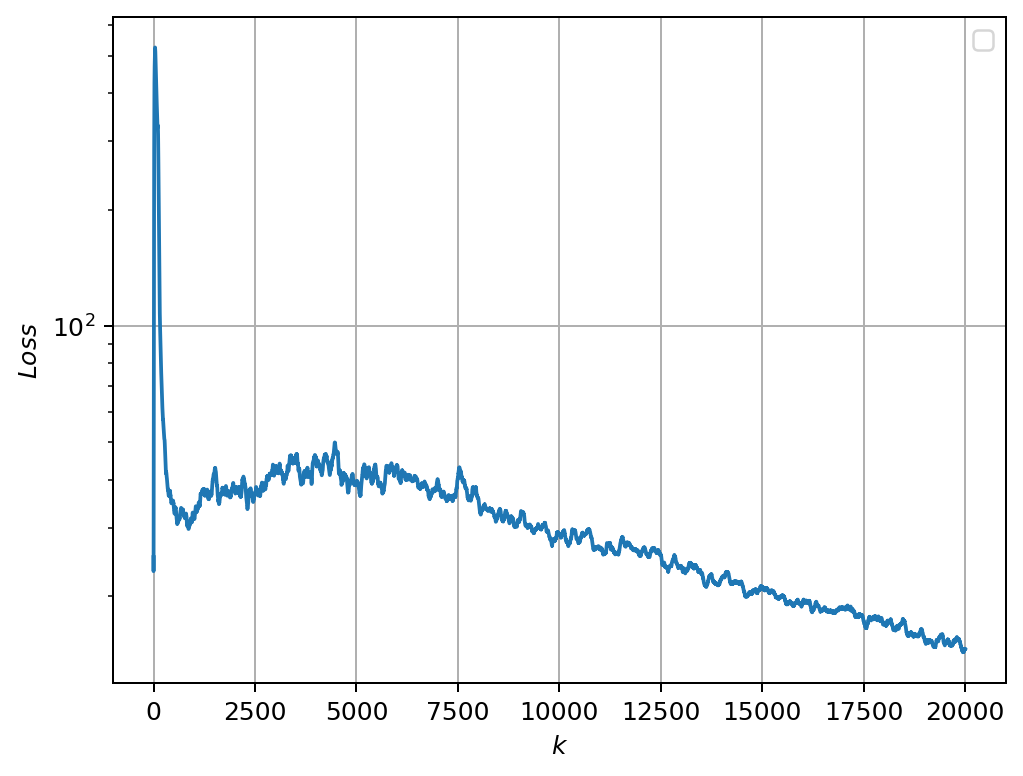

In [10]:
run(link, df_link, ['000'], id = 'pred_vtime', load = True)